In [3]:
!pip install yfinance pandas numpy matplotlib seaborn

ERROR: Could not install packages due to an OSError: HTTPSConnectionPool(host='files.pythonhosted.org', port=443): Max retries exceeded with url: /packages/2b/53/ba0f45c93c45cafe010c9fe2f509c70d1ad0f96ae7b6ca93369db0c17942/yfinance-1.5.1-py2.py3-none-any.whl.metadata (Caused by NewConnectionError('<pip._vendor.urllib3.connection.HTTPSConnection object at 0x000001A970F4F110>: Failed to establish a new connection: [Errno 11002] getaddrinfo failed'))



In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download 5 years of AAPL data
df = yf.download("AAPL", period="5y")

# Save a raw copy immediately — good practice, this is your "original" backup
df.to_csv("AAPL_raw.csv")

print(df.shape)
df.head()

ModuleNotFoundError: No module named 'yfinance'

In [4]:
!pip install --trusted-host pypi.org --trusted-host files.pythonhosted.org yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 773.2 kB/s eta 0:00:02
   ------------------ --------------------- 0.8/1.7 MB 740.0 kB/s eta 0:00:02
   ------------------ --------------------- 0.8/1.7 MB 740.0 kB/s eta 0:00:02
   ------------------ --------------------- 0.8/1.7 MB 740.0 kB/s eta 0:00:02
   ------------------------- -------------- 1.0/1.7 MB 598.6 kB/s eta 0:00:02
   ------------------------- -------------- 1.0/1.7 MB 598

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = yf.download("AAPL", period="5y")

print(df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed

(1255, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-07-02,136.426300,136.465284,134.272092,134.418298,78852600
2021-07-06,138.434265,139.535725,136.533502,136.533502,108181800
2021-07-07,140.919922,141.231835,139.058142,139.915914,104911600
2021-07-08,139.623505,140.422794,137.118384,138.005412,105575500
2021-07-09,141.446259,141.972618,139.048362,139.145843,99890800


In [7]:
# Flatten the multi-level columns
df.columns = df.columns.get_level_values(0)
df = df.reset_index()

# Save a clean local copy so you don't need internet again
df.to_csv("AAPL_5y.csv", index=False)

print(df.shape)
df.head()

(1255, 6)


Price,Date,Close,High,Low,Open,Volume
0,2021-07-02,136.426300,136.465284,134.272092,134.418298,78852600
1,2021-07-06,138.434265,139.535725,136.533502,136.533502,108181800
2,2021-07-07,140.919922,141.231835,139.058142,139.915914,104911600
3,2021-07-08,139.623505,140.422794,137.118384,138.005412,105575500
4,2021-07-09,141.446259,141.972618,139.048362,139.145843,99890800


In [8]:
# Basic info
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDate range:", df['Date'].min(), "to", df['Date'].max())

df.describe()

Shape: (1255, 6)

Data types:
Price
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

Missing values:
Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Duplicate rows: 0

Date range: 2021-07-02 00:00:00 to 2026-07-02 00:00:00


Price,Date,Close,High,Low,Open,Volume
count,1255,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,2023-12-31 04:35:22.709163264,193.935209,195.876317,191.834416,193.743302,6.528386e+07
min,2021-07-02 00:00:00,122.933548,125.637653,122.097730,123.907033,1.791060e+07
25%,2022-09-29 12:00:00,156.586403,159.108328,154.520841,156.820421,4.575730e+07
50%,2023-12-29 00:00:00,182.708572,184.404792,180.846017,182.343679,5.726670e+07
75%,2025-04-01 12:00:00,226.567451,228.692262,224.440934,226.804816,7.738550e+07
max,2026-07-02 00:00:00,315.200012,317.399994,309.649994,314.179993,3.186799e+08
std,NaN,44.916606,45.306195,44.554198,44.917990,2.874899e+07


In [9]:
# Ensure sorted by date (oldest to newest)
df = df.sort_values('Date').reset_index(drop=True)

# Set Date as the index — essential for time-series operations (rolling, resampling)
df.set_index('Date', inplace=True)

print(df.index.min(), "to", df.index.max())
df.head()

2021-07-02 00:00:00 to 2026-07-02 00:00:00


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-07-02,136.426300,136.465284,134.272092,134.418298,78852600
2021-07-06,138.434265,139.535725,136.533502,136.533502,108181800
2021-07-07,140.919922,141.231835,139.058142,139.915914,104911600
2021-07-08,139.623505,140.422794,137.118384,138.005412,105575500
2021-07-09,141.446259,141.972618,139.048362,139.145843,99890800


In [10]:
# Remove the leftover "Price" label above the columns
df.columns.name = None

df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2021-07-02,136.426300,136.465284,134.272092,134.418298,78852600
2021-07-06,138.434265,139.535725,136.533502,136.533502,108181800
2021-07-07,140.919922,141.231835,139.058142,139.915914,104911600
2021-07-08,139.623505,140.422794,137.118384,138.005412,105575500
2021-07-09,141.446259,141.972618,139.048362,139.145843,99890800


In [11]:
# 1. Daily Price Change (absolute)
df['Daily_Change'] = df['Close'] - df['Open']

# 2. Daily Percentage Change
df['Daily_Pct_Change'] = df['Close'].pct_change() * 100

# 3. Moving Averages (7-day and 30-day)
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()

# 4. Volatility (30-day rolling standard deviation of daily returns)
df['Volatility_30'] = df['Daily_Pct_Change'].rolling(window=30).std()

# 5. Daily Trading Range (High - Low) — bonus feature, shows intraday volatility
df['Daily_Range'] = df['High'] - df['Low']

df[['Close','Daily_Change','Daily_Pct_Change','MA_7','MA_30','Volatility_30','Daily_Range']].head(35)

,Close,Daily_Change,Daily_Pct_Change,MA_7,MA_30,Volatility_30,Daily_Range
Date,,,,,,,
2021-07-02,136.426300,2.008002,NaN,NaN,NaN,NaN,2.193192
2021-07-06,138.434265,1.900763,1.471831,NaN,NaN,NaN,3.002223
2021-07-07,140.919922,1.004008,1.795550,NaN,NaN,NaN,2.173693
2021-07-08,139.623505,1.618092,-0.919967,NaN,NaN,NaN,3.304409
2021-07-09,141.446259,2.300415,1.305478,NaN,NaN,NaN,2.924256
2021-07-12,140.851639,-1.666832,-0.420386,NaN,NaN,NaN,2.261431
2021-07-13,141.962875,1.569351,0.788941,139.952109,NaN,NaN,3.733302
2021-07-14,145.384262,1.023478,2.410057,141.231818,NaN,NaN,1.842296
2021-07-15,144.731171,-0.740821,-0.449217,142.131376,NaN,NaN,2.836532


In [12]:
# Monthly Returns — % change in price from the start to end of each calendar month
monthly = df['Close'].resample('ME').last()
monthly_returns = monthly.pct_change() * 100

print("Monthly Returns (%):")
monthly_returns.tail(12)

Monthly Returns (%):


Date
2025-08-31    11.963892
2025-09-30     9.688122
2025-10-31     6.181521
2025-11-30     3.236417
2025-12-31    -2.506729
2026-01-31    -4.553809
2026-02-28     1.906580
2026-03-31    -3.932929
2026-04-30     6.919120
2026-05-31    15.108709
2026-06-30    -7.274246
2026-07-31     5.612393
Freq: ME, Name: Close, dtype: float64

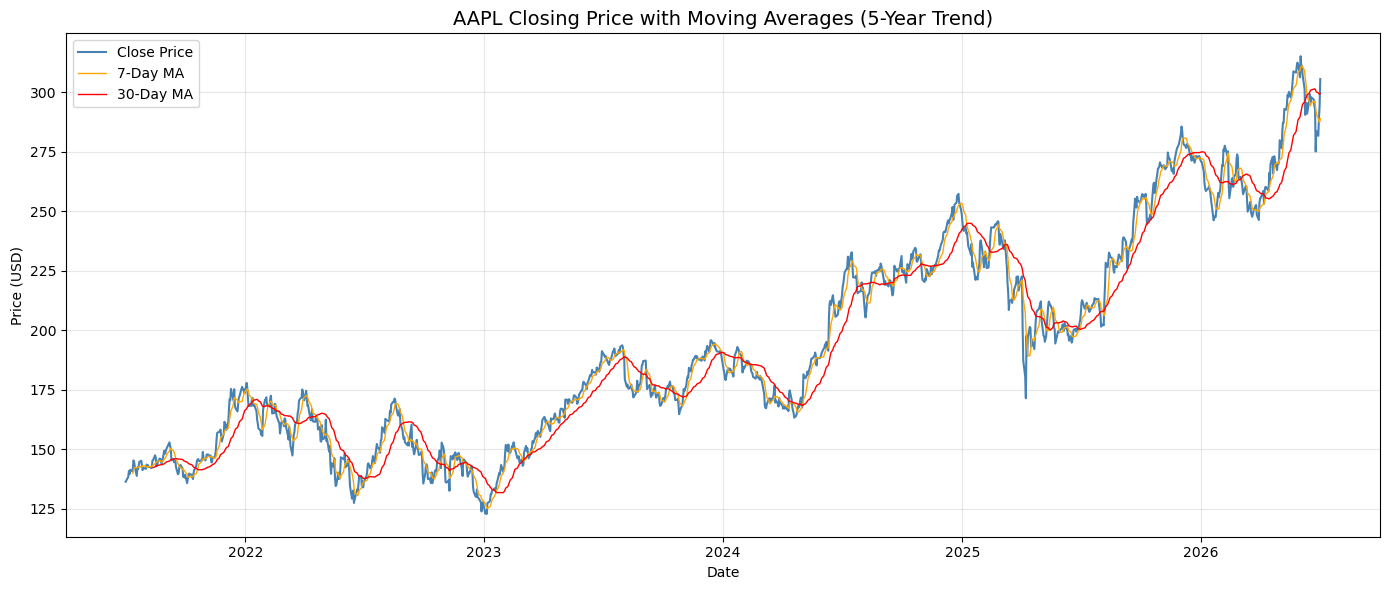

In [13]:
# Closing price trend (with moving averages overlaid)
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Close'], label='Close Price', color='steelblue', linewidth=1.5)
plt.plot(df.index, df['MA_7'], label='7-Day MA', color='orange', linewidth=1)
plt.plot(df.index, df['MA_30'], label='30-Day MA', color='red', linewidth=1)
plt.title('AAPL Closing Price with Moving Averages (5-Year Trend)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aapl_price_trend.png', dpi=150)
plt.show()

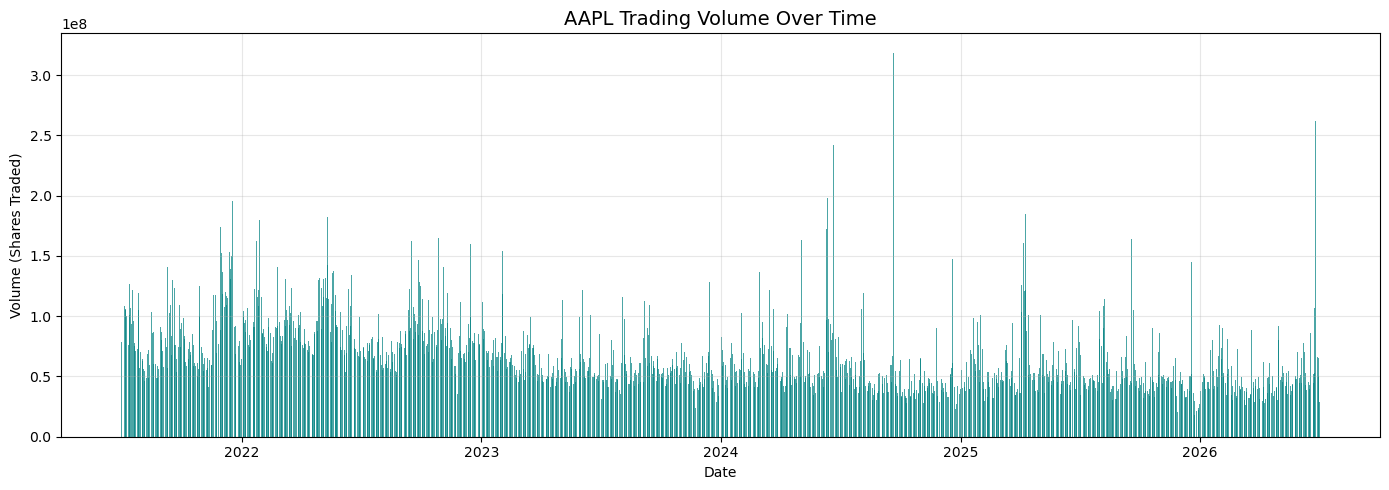

In [14]:
# Trading Volume Trend
plt.figure(figsize=(14,5))
plt.bar(df.index, df['Volume'], color='teal', width=1.5, alpha=0.7)
plt.title('AAPL Trading Volume Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volume (Shares Traded)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aapl_volume_trend.png', dpi=150)
plt.show()

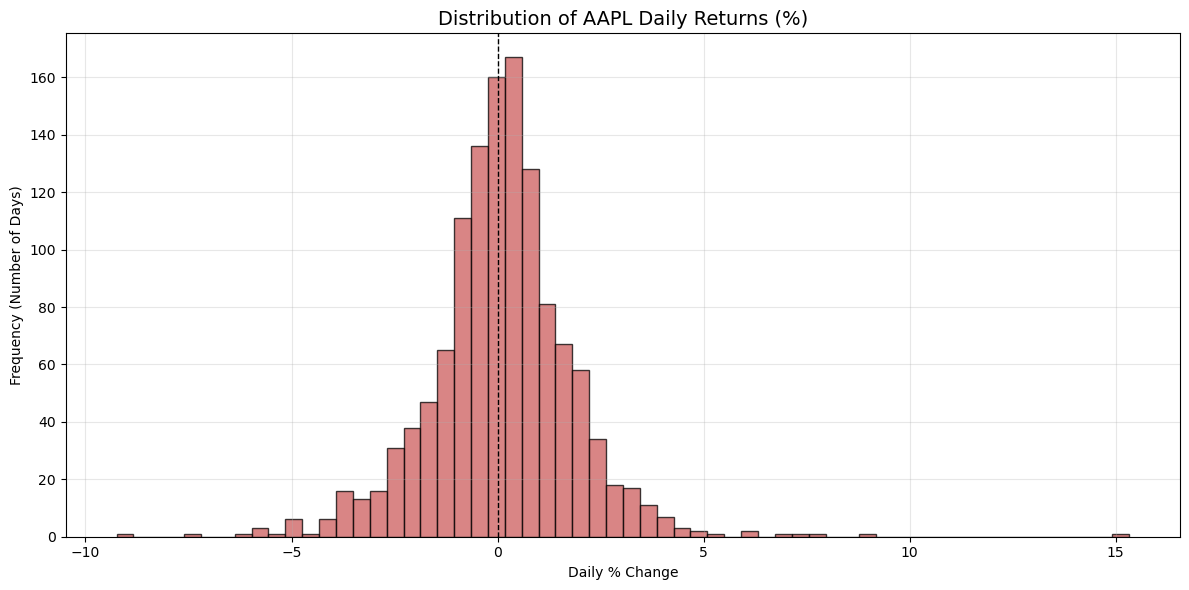

In [15]:
# Daily Returns Distribution
plt.figure(figsize=(12,6))
plt.hist(df['Daily_Pct_Change'].dropna(), bins=60, color='indianred', alpha=0.75, edgecolor='black')
plt.title('Distribution of AAPL Daily Returns (%)', fontsize=14)
plt.xlabel('Daily % Change')
plt.ylabel('Frequency (Number of Days)')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aapl_returns_distribution.png', dpi=150)
plt.show()

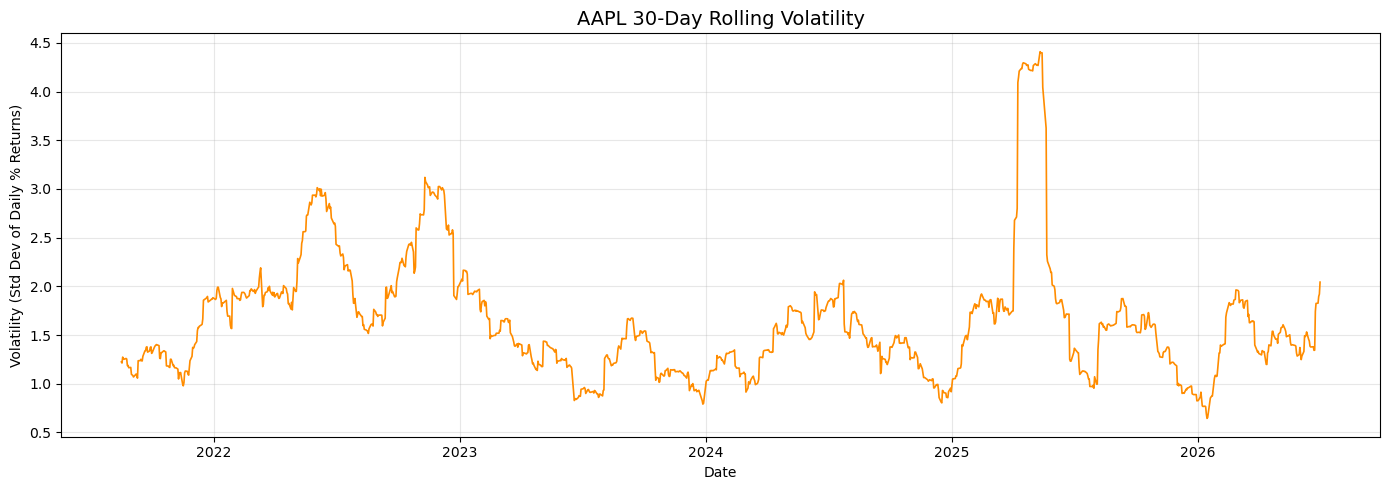

In [16]:
# Volatility Over Time
plt.figure(figsize=(14,5))
plt.plot(df.index, df['Volatility_30'], color='darkorange', linewidth=1.2)
plt.title('AAPL 30-Day Rolling Volatility', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volatility (Std Dev of Daily % Returns)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aapl_volatility_trend.png', dpi=150)
plt.show()

## Key Findings & Conclusions

1. **Overall Growth**: Apple's stock price roughly doubled over the 5-year period, moving from a low of ~\$123 to a high of ~\$315.

2. **Growth Phases**: The stock experienced two major upward phases (2023–2024 and 2025–2026), separated by a notable correction in early-to-mid 2025.

3. **Volatility Spike**: A significant spike in both volatility and trading volume occurred around early-to-mid 2025, coinciding with a sharp price drop — suggesting a major market event or company-specific news during that period.

4. **Daily Risk Profile**: Daily returns are tightly clustered near 0%, indicating Apple is relatively low-risk on a day-to-day basis. However, the stock occasionally experiences sharp single-day moves (up to +15%), likely driven by earnings reports or major announcements.

5. **Monthly Performance**: Monthly returns show more positive months than negative ones over the period, consistent with the long-term upward trend.

### Recommendations
- Investors seeking stability may find Apple's low day-to-day volatility appealing, but should be aware of periodic sharp corrections.
- Further investigation into the early-to-mid 2025 volatility spike (e.g. cross-referencing with Apple's earnings calendar or major news events) would strengthen the analysis.
- The consistent uptrend across moving averages suggests a positive long-term momentum, though past performance does not guarantee future results.